**Smile Dynamics and Rough Volatility**

Reproduce some of the figures from the paper 

- Bourgey, F., De Marco, S., & Delemotte, J. (2024). 
 _Smile Dynamics and Rough Volatility_. Available at [SSRN 4911186](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=4911186)


> Note: this code does not use GPUs.

# Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from utils import non_uniform_grid, set_matplotlib_style
from rough_heston import RoughHestonModel, get_params_rough_heston
from rough_bergomi import RoughBergomiModel
from two_bergomi import TwoFactorBergomiModel, get_params_two_factor_bergomi
from heston import HestonModel
from data import get_params, get_xi0_interpolator, DATES

set_matplotlib_style()
SEED = 1234

# Two-factor Bergomi model

Reproduces Figure 3

In [3]:
params, xi0 = get_params_two_factor_bergomi(id=1)
two_bergomi = TwoFactorBergomiModel(params=params, xi0=xi0)
two_bergomi

TwoFactorBergomiModel with parameters:
w=3.48, k1=5.25, k2=0.28, theta=0.245, rho12=0.0, rhoS1=-0.759, rhoS2=-0.487, s0=1.0

In [4]:
# Simulation parameters
n_mc = 3 * 10**5
n_disc = 300
n_quad = 40
eps_ssr = 1e-3

params_mc = {
    "n_mc": n_mc,
    "n_disc": n_disc,
    "n_quad": n_quad,
    "seed": SEED,
    "eps_ssr": eps_ssr,
    "conditioning": True,
    "n_loop": 6,
}

In [5]:
# Shorter maturities
Ts = np.linspace(1 / 365, 3, 20)
out = two_bergomi.ssr_all(T=Ts, **params_mc)


Computing SSR:
----------------
Model: TwoFactorBergomiModel
Parameters:
Maturity T:  [2.73972603e-03 1.60490267e-01 3.18240807e-01 4.75991348e-01
 6.33741889e-01 7.91492430e-01 9.49242970e-01 1.10699351e+00
 1.26474405e+00 1.42249459e+00 1.58024513e+00 1.73799567e+00
 1.89574621e+00 2.05349676e+00 2.21124730e+00 2.36899784e+00
 2.52674838e+00 2.68449892e+00 2.84224946e+00 3.00000000e+00]
Monte Carlo paths: 300000
Number of time steps: 300
Finite difference perturbation for SSR: 0.001
Number of simulation loops: 6
Number of independent batches: 1

1/20: expiry 0.0027
2/20: expiry 0.1605
3/20: expiry 0.3182
4/20: expiry 0.4760
5/20: expiry 0.6337
6/20: expiry 0.7915
7/20: expiry 0.9492
8/20: expiry 1.1070
9/20: expiry 1.2647
10/20: expiry 1.4225
11/20: expiry 1.5802
12/20: expiry 1.7380
13/20: expiry 1.8957
14/20: expiry 2.0535
15/20: expiry 2.2112
16/20: expiry 2.3690
17/20: expiry 2.5267
18/20: expiry 2.6845
19/20: expiry 2.8422
20/20: expiry 3.0000


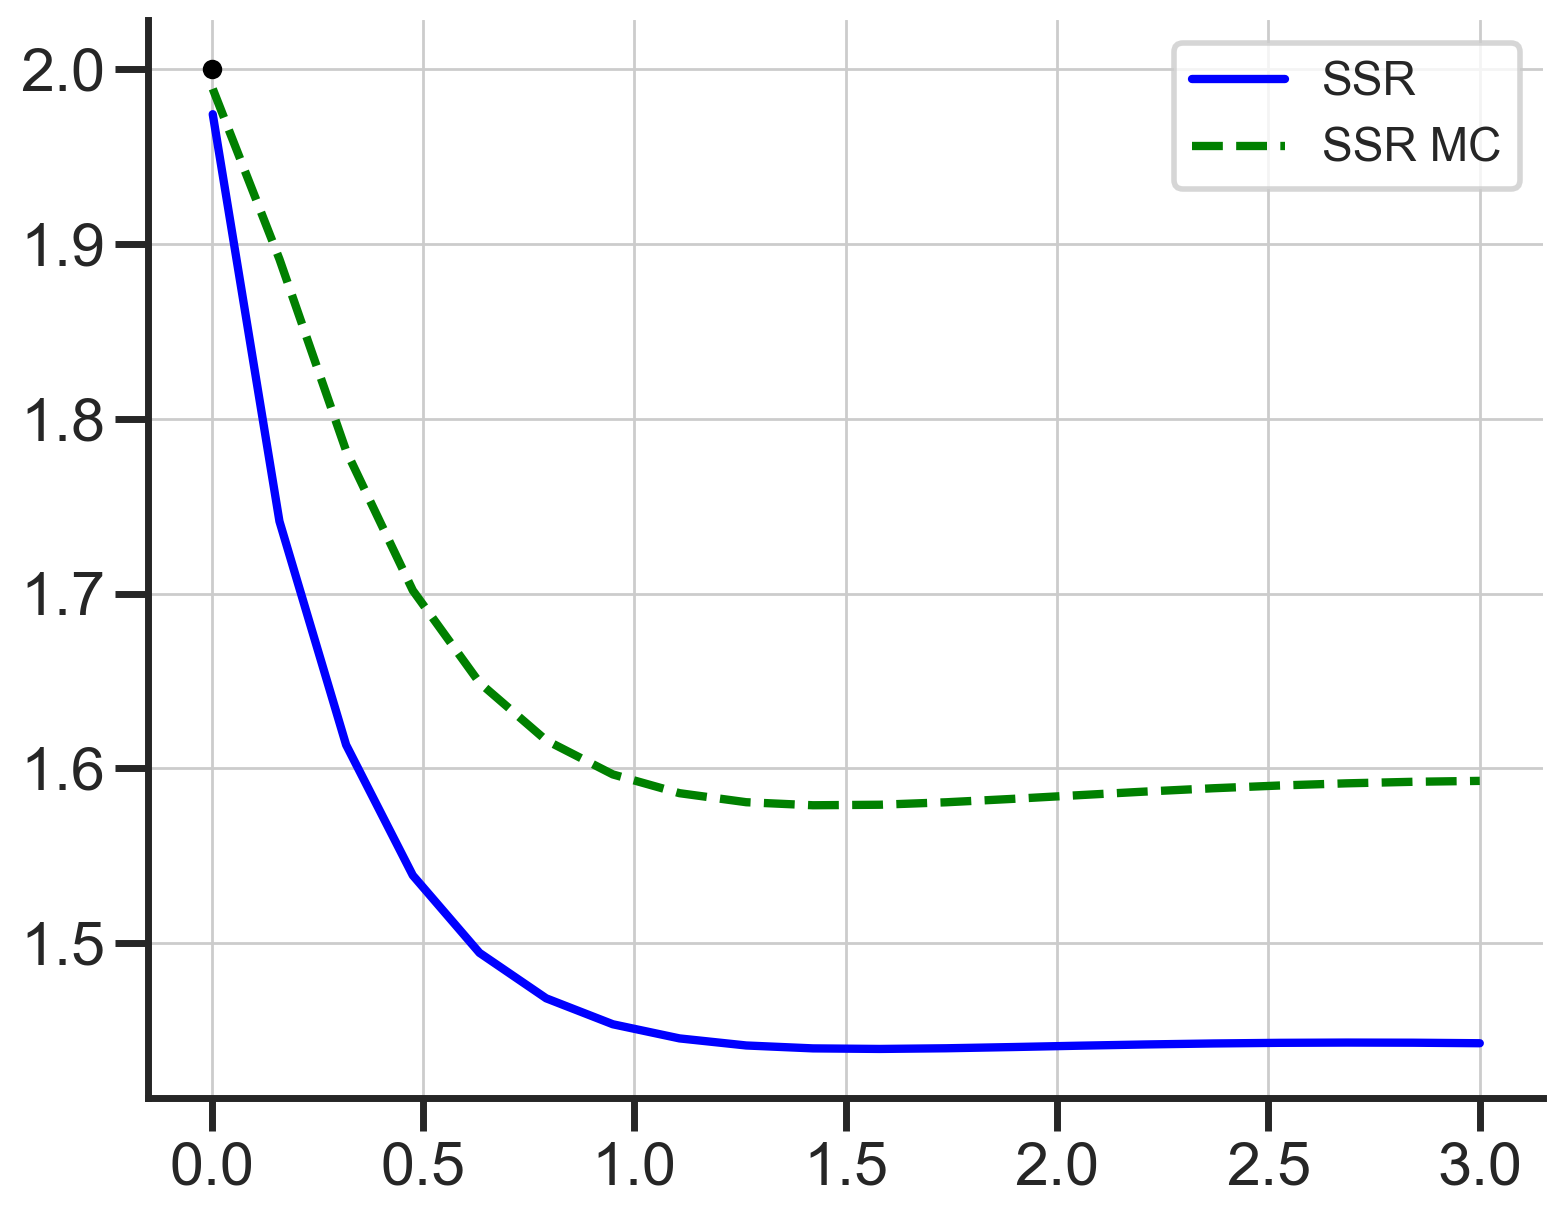

In [6]:
fig, ax = plt.subplots()
ax.plot(Ts, out["ssr_fd"], "b-", label="SSR")
ax.plot(Ts, out["ssr_vs"], "g--", label="SSR MC")
ax.plot([0], [2], ".k")
ax.legend()
plt.show()

In [7]:
# Longer maturities
Ts_long = np.linspace(1 / 365, 10, 20)
out_long = two_bergomi.ssr_all(T=Ts_long, **params_mc)


Computing SSR:
----------------
Model: TwoFactorBergomiModel
Parameters:
Maturity T:  [2.73972603e-03 5.28911319e-01 1.05508291e+00 1.58125451e+00
 2.10742610e+00 2.63359769e+00 3.15976929e+00 3.68594088e+00
 4.21211247e+00 4.73828407e+00 5.26445566e+00 5.79062725e+00
 6.31679885e+00 6.84297044e+00 7.36914203e+00 7.89531363e+00
 8.42148522e+00 8.94765681e+00 9.47382841e+00 1.00000000e+01]
Monte Carlo paths: 300000
Number of time steps: 300
Finite difference perturbation for SSR: 0.001
Number of simulation loops: 6
Number of independent batches: 1

1/20: expiry 0.0027
2/20: expiry 0.5289
3/20: expiry 1.0551
4/20: expiry 1.5813
5/20: expiry 2.1074
6/20: expiry 2.6336
7/20: expiry 3.1598
8/20: expiry 3.6859
9/20: expiry 4.2121
10/20: expiry 4.7383
11/20: expiry 5.2645
12/20: expiry 5.7906
13/20: expiry 6.3168
14/20: expiry 6.8430
15/20: expiry 7.3691
16/20: expiry 7.8953
17/20: expiry 8.4215
18/20: expiry 8.9477
19/20: expiry 9.4738
20/20: expiry 10.0000


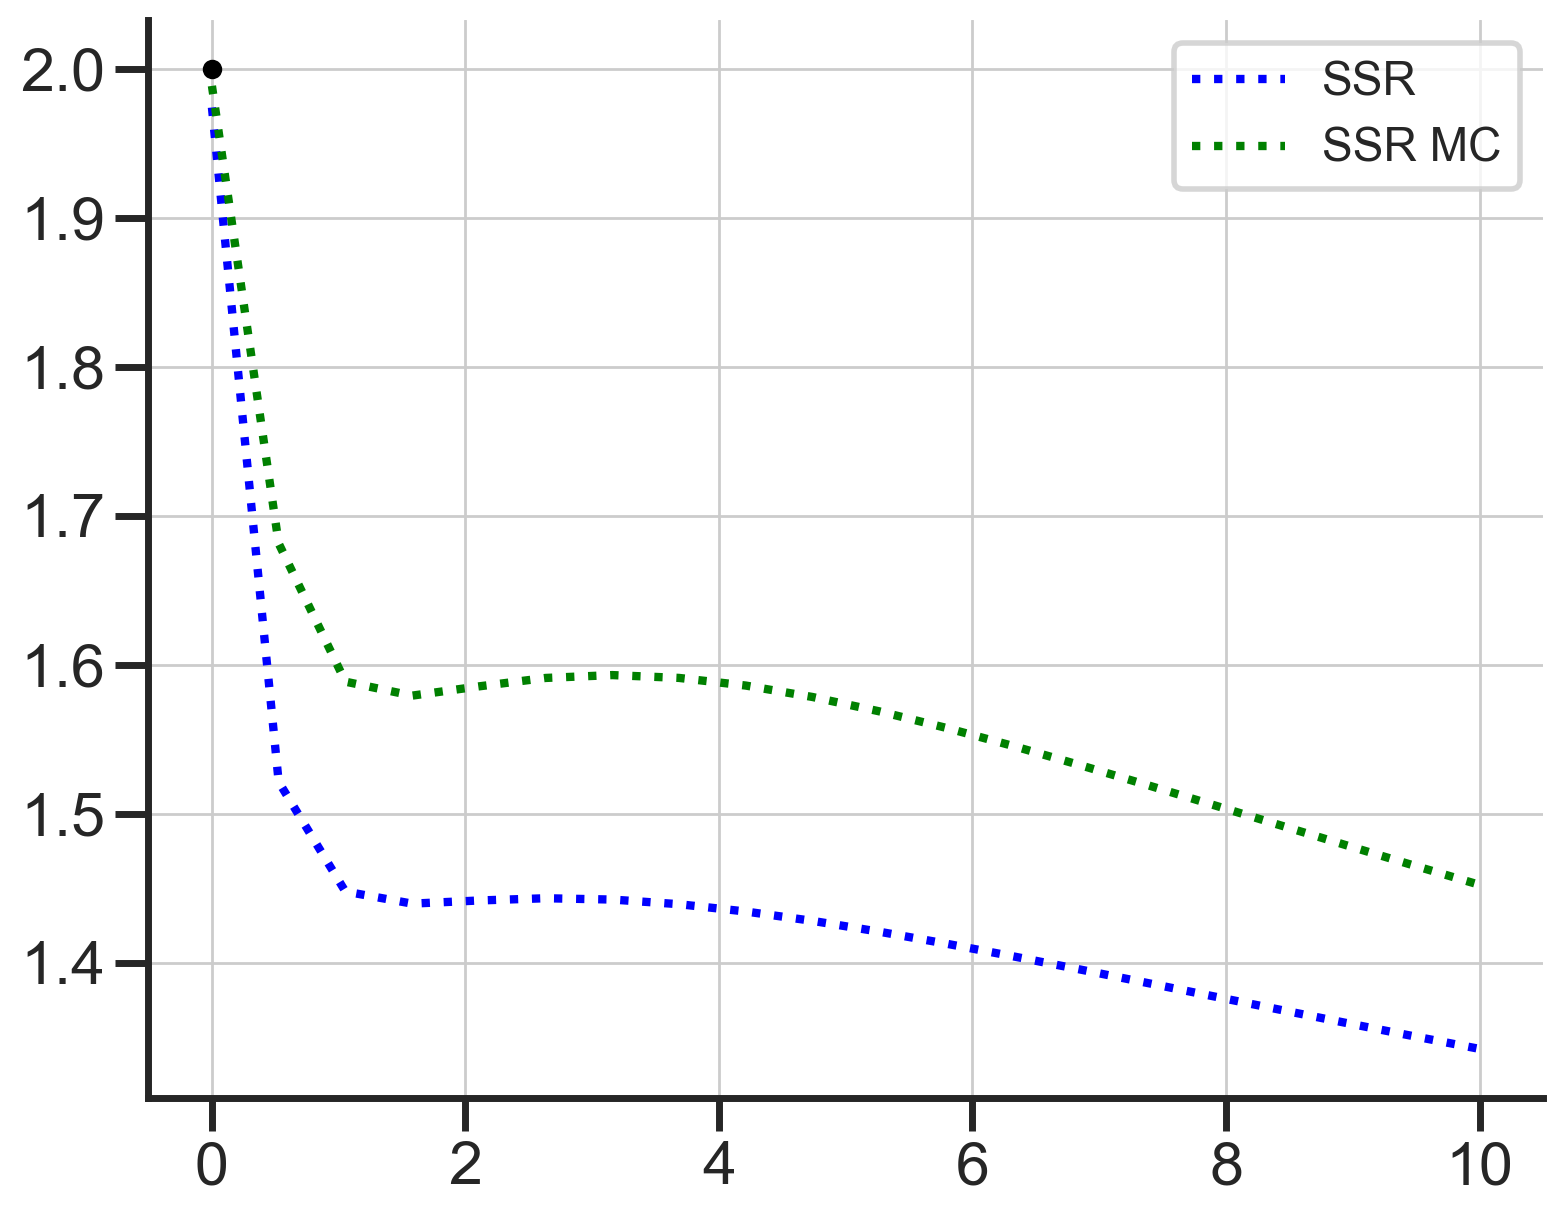

In [8]:
fig, ax = plt.subplots()
ax.plot(Ts_long, out_long["ssr_fd"], "b:", label="SSR")
ax.plot(Ts_long, out_long["ssr_vs"], "g:", label="SSR MC")
ax.plot([0], [2], ".k")
ax.legend()
plt.show()

# Rough Bergomi

Reproduces Figure 4

In [9]:
xi0 = lambda t: 0.23**2 * np.ones_like(t)
params_base = {"eta": 1.9, "rho": -0.9}

rbergomi_007 = RoughBergomiModel(params=params_base | {"H": 0.07}, xi0=xi0)
rbergomi_01 = RoughBergomiModel(params=params_base | {"H": 0.1}, xi0=xi0)
rbergomi_03 = RoughBergomiModel(params=params_base | {"H": 0.3}, xi0=xi0)
rbergomi_05 = RoughBergomiModel(params=params_base | {"H": 0.5}, xi0=xi0)

## H=0.1

In [10]:
Ts = np.linspace(1e-3, 3, 30)
n_mc = 3 * 10**5
n_disc = 300
n_quad = 40
eps_ssr = 1e-4

out_01 = rbergomi_01.ssr_all(
    T=Ts,
    n_mc=n_mc,
    n_disc=n_disc,
    n_quad=n_quad,
    seed=SEED,
    eps_ssr=eps_ssr,
    conditioning=True,
    n_loop=6,
)


Computing SSR:
----------------
Model: RoughBergomiModel
Parameters:
Maturity T:  [1.00000000e-03 1.04413793e-01 2.07827586e-01 3.11241379e-01
 4.14655172e-01 5.18068966e-01 6.21482759e-01 7.24896552e-01
 8.28310345e-01 9.31724138e-01 1.03513793e+00 1.13855172e+00
 1.24196552e+00 1.34537931e+00 1.44879310e+00 1.55220690e+00
 1.65562069e+00 1.75903448e+00 1.86244828e+00 1.96586207e+00
 2.06927586e+00 2.17268966e+00 2.27610345e+00 2.37951724e+00
 2.48293103e+00 2.58634483e+00 2.68975862e+00 2.79317241e+00
 2.89658621e+00 3.00000000e+00]
Monte Carlo paths: 300000
Number of time steps: 300
Finite difference perturbation for SSR: 0.0001
Number of simulation loops: 6
Number of independent batches: 1

1/30: expiry 0.0010
2/30: expiry 0.1044
3/30: expiry 0.2078
4/30: expiry 0.3112
5/30: expiry 0.4147
6/30: expiry 0.5181
7/30: expiry 0.6215
8/30: expiry 0.7249
9/30: expiry 0.8283
10/30: expiry 0.9317
11/30: expiry 1.0351
12/30: expiry 1.1386
13/30: expiry 1.2420
14/30: expiry 1.3454
15/30: exp

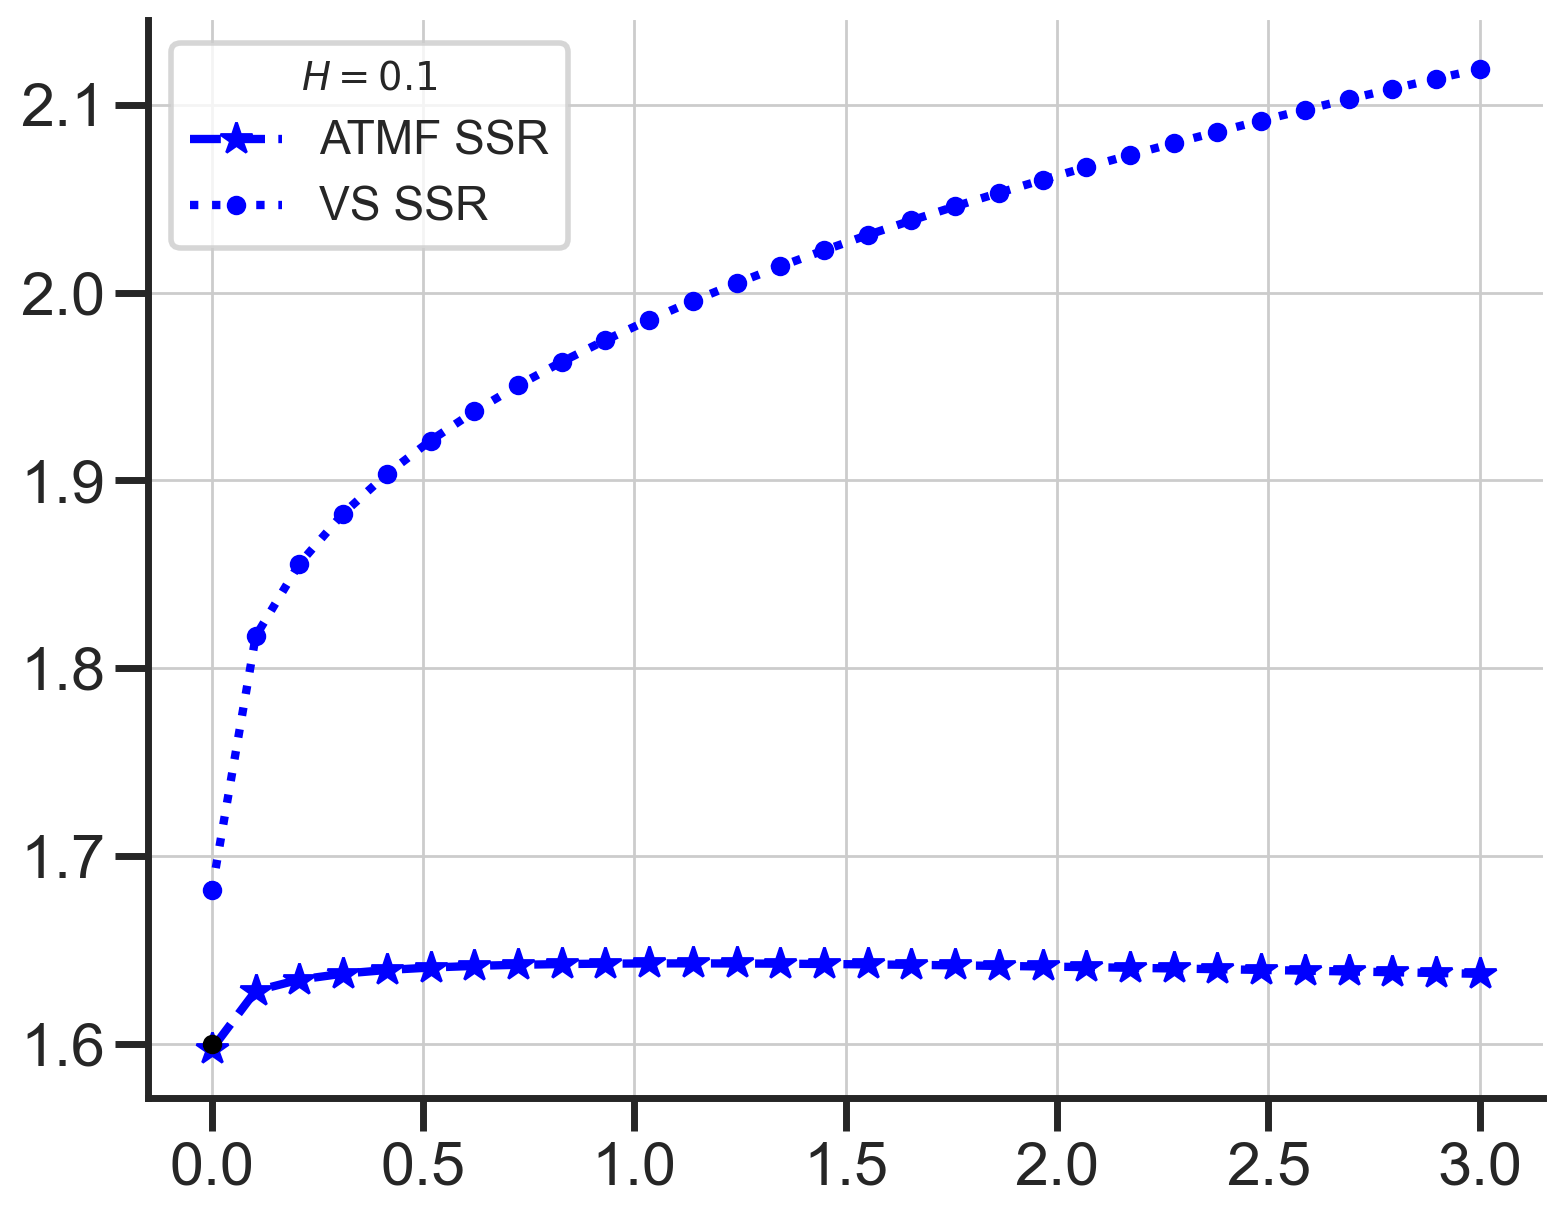

In [11]:
fig, ax = plt.subplots()
ax.plot(Ts, out_01["ssr_fd"], "b*--", label="ATMF SSR")
ax.plot(Ts, out_01["ssr_vs"], "b:.", label="VS SSR")
ax.legend(title=rf"$H={rbergomi_01.H}$")
ax.plot([0], [rbergomi_01.H + 3 / 2], ".k")
plt.show()

## H=0.3

In [12]:
Ts = np.linspace(1e-3, 3, 30)
n_mc = 3 * 10**5
n_disc = 300
n_quad = 40
eps_ssr = 1e-4

out_03 = rbergomi_03.ssr_all(
    T=Ts,
    n_mc=n_mc,
    n_disc=n_disc,
    n_quad=n_quad,
    seed=SEED,
    eps_ssr=eps_ssr,
    conditioning=True,
    n_loop=6,
)


Computing SSR:
----------------
Model: RoughBergomiModel
Parameters:
Maturity T:  [1.00000000e-03 1.04413793e-01 2.07827586e-01 3.11241379e-01
 4.14655172e-01 5.18068966e-01 6.21482759e-01 7.24896552e-01
 8.28310345e-01 9.31724138e-01 1.03513793e+00 1.13855172e+00
 1.24196552e+00 1.34537931e+00 1.44879310e+00 1.55220690e+00
 1.65562069e+00 1.75903448e+00 1.86244828e+00 1.96586207e+00
 2.06927586e+00 2.17268966e+00 2.27610345e+00 2.37951724e+00
 2.48293103e+00 2.58634483e+00 2.68975862e+00 2.79317241e+00
 2.89658621e+00 3.00000000e+00]
Monte Carlo paths: 300000
Number of time steps: 300
Finite difference perturbation for SSR: 0.0001
Number of simulation loops: 6
Number of independent batches: 1

1/30: expiry 0.0010
2/30: expiry 0.1044
3/30: expiry 0.2078
4/30: expiry 0.3112
5/30: expiry 0.4147
6/30: expiry 0.5181
7/30: expiry 0.6215
8/30: expiry 0.7249
9/30: expiry 0.8283
10/30: expiry 0.9317
11/30: expiry 1.0351
12/30: expiry 1.1386
13/30: expiry 1.2420
14/30: expiry 1.3454
15/30: exp

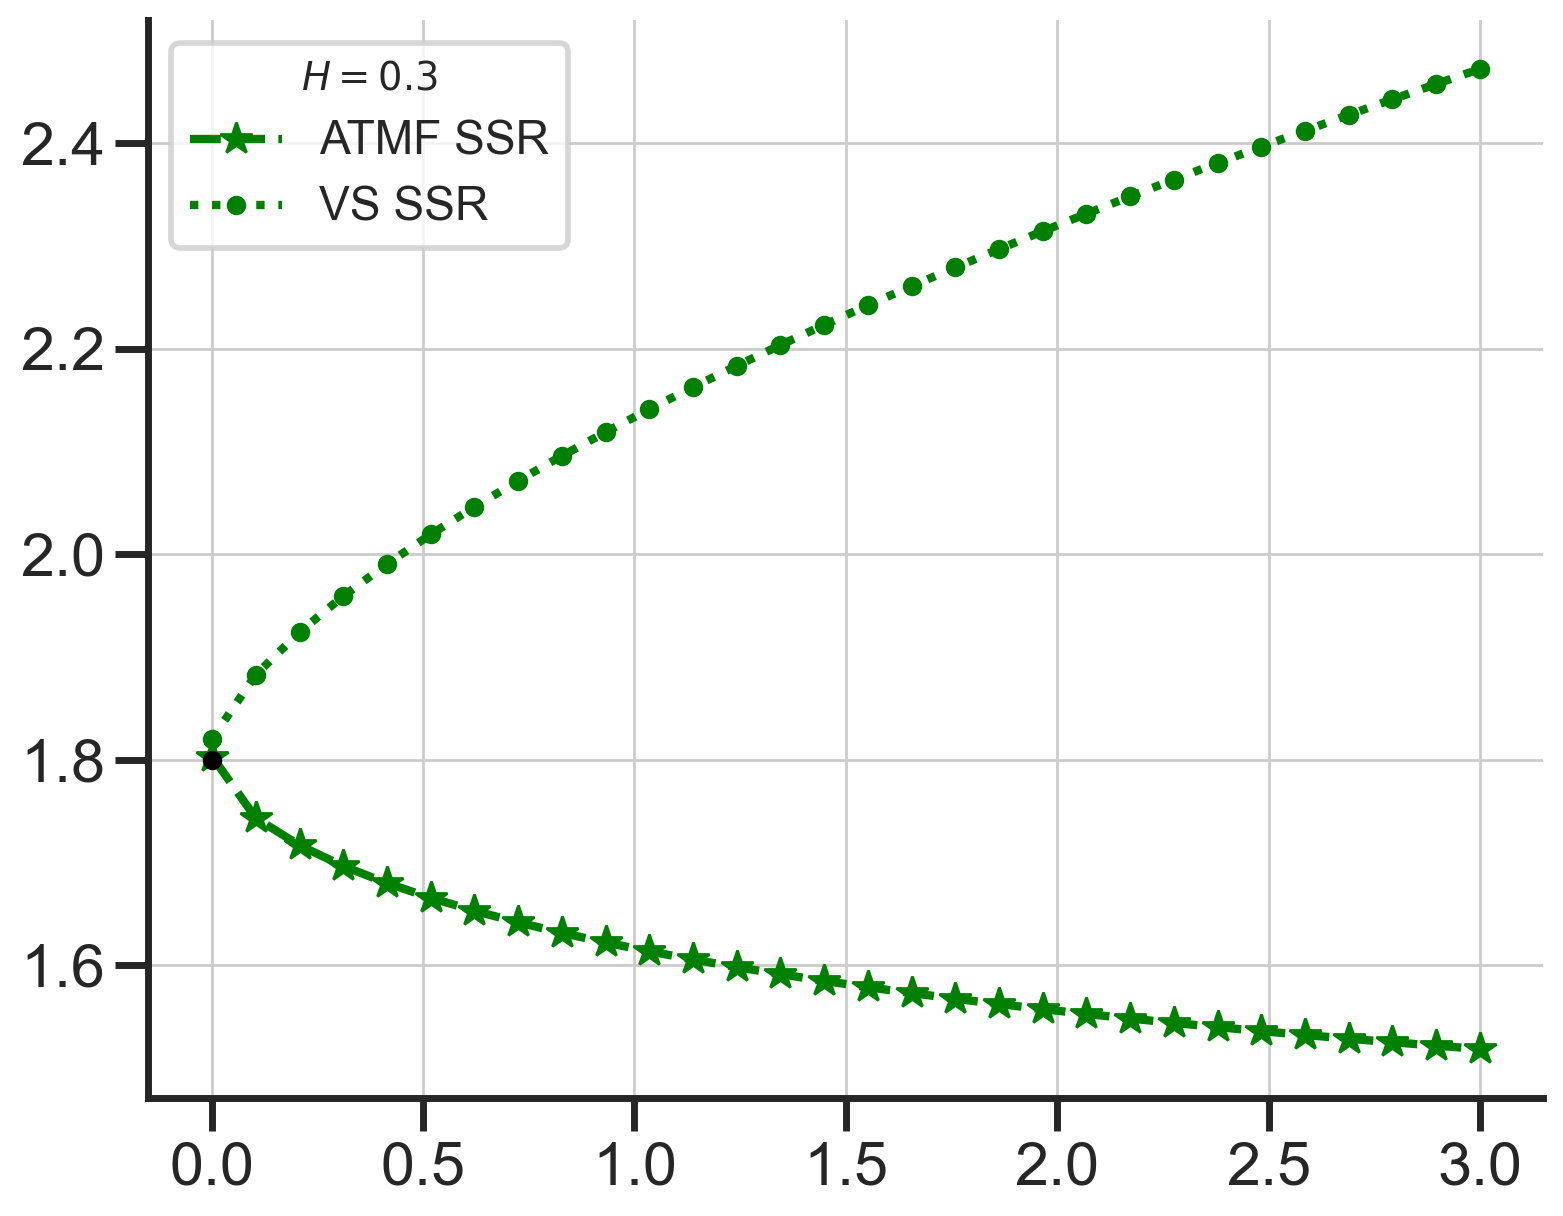

In [13]:
fig, ax = plt.subplots()
ax.plot(Ts, out_03["ssr_fd"], "g*--", label="ATMF SSR")
ax.plot(Ts, out_03["ssr_vs"], "g:.", label="VS SSR")
ax.legend(title=rf"$H={rbergomi_03.H}$")
ax.plot([0], [rbergomi_03.H + 3 / 2], ".k")
plt.show()

## H=0.5

In [14]:
Ts = np.linspace(1e-2, 3, 15)
n_mc = 3 * 10**5
n_disc = 300
n_quad = 40
eps_ssr = 1e-4

out_05 = rbergomi_05.ssr_all(
    T=Ts,
    n_mc=n_mc,
    n_disc=n_disc,
    n_quad=n_quad,
    seed=SEED,
    eps_ssr=eps_ssr,
    conditioning=True,
    n_loop=6,
)


Computing SSR:
----------------
Model: RoughBergomiModel
Parameters:
Maturity T:  [0.01       0.22357143 0.43714286 0.65071429 0.86428571 1.07785714
 1.29142857 1.505      1.71857143 1.93214286 2.14571429 2.35928571
 2.57285714 2.78642857 3.        ]
Monte Carlo paths: 300000
Number of time steps: 300
Finite difference perturbation for SSR: 0.0001
Number of simulation loops: 6
Number of independent batches: 1

1/15: expiry 0.0100
2/15: expiry 0.2236
3/15: expiry 0.4371
4/15: expiry 0.6507
5/15: expiry 0.8643
6/15: expiry 1.0779
7/15: expiry 1.2914
8/15: expiry 1.5050
9/15: expiry 1.7186
10/15: expiry 1.9321
11/15: expiry 2.1457
12/15: expiry 2.3593
13/15: expiry 2.5729
14/15: expiry 2.7864
15/15: expiry 3.0000


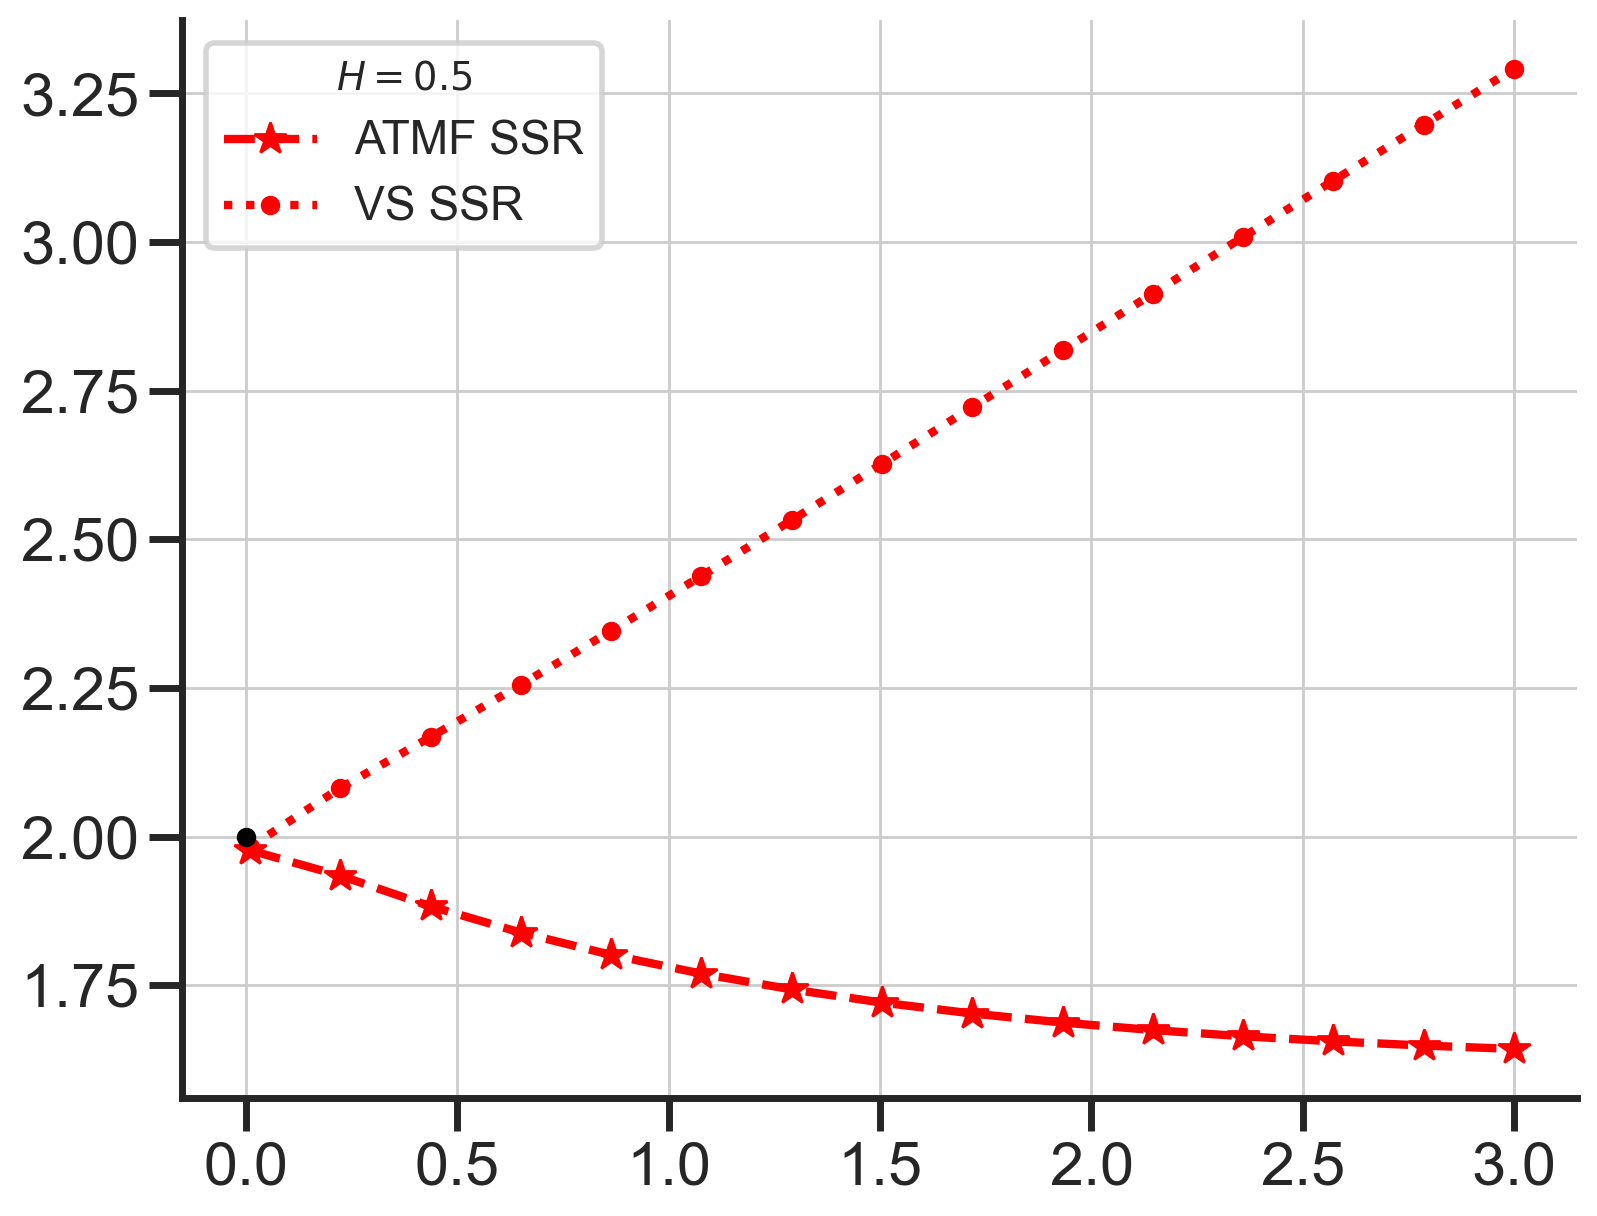

In [15]:
fig, ax = plt.subplots()
ax.plot(Ts, out_05["ssr_fd"], "r*--", label="ATMF SSR")
ax.plot(Ts, out_05["ssr_vs"], "r:.", label="VS SSR")
ax.legend(title=rf"$H={rbergomi_05.H}$")
ax.plot([0], [rbergomi_05.H + 3 / 2], ".k")
plt.show()

# Rough Heston

In [16]:
n_pade = 5
n_quad = 50
Ts = non_uniform_grid(1e-2, 3, 15, 2)

## H=0.1

In [17]:
H = 0.1
params, xi0 = get_params_rough_heston(id=1)
params["H"] = H
rheston = RoughHestonModel(params=params, xi0=xi0)
Ts = non_uniform_grid(1e-5, 3, 15, 3)
ssr_vs = rheston.ssr_vs(Ts, n_pade=n_pade, n_quad=n_quad)
ssr_cf = rheston.ssr_cf(Ts, n_pade=n_pade, n_quad=n_quad)

/Users/florianbourgey/projects/ssr/.venv/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/florianbourgey/projects/ssr/.venv/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


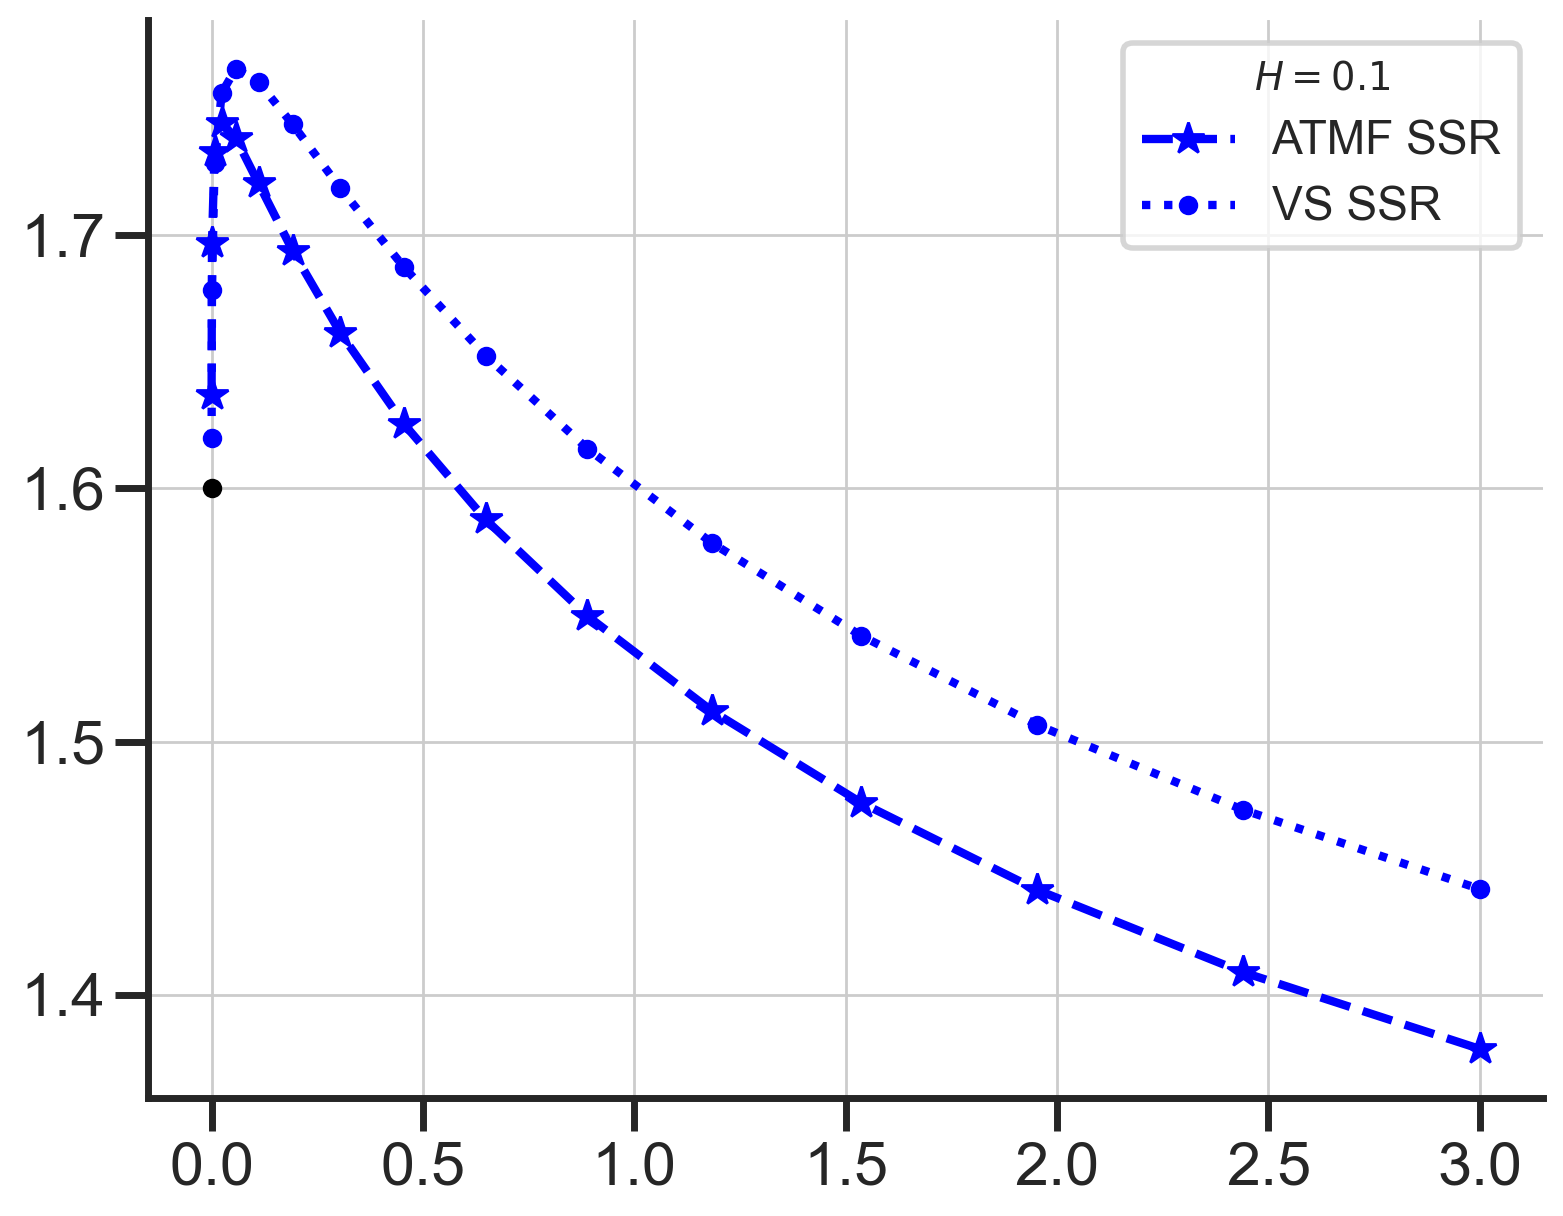

In [18]:
fig, ax = plt.subplots()
ax.plot(Ts, ssr_cf, "*--", color="blue", label="ATMF SSR")
ax.plot(Ts, ssr_vs, ":.", color="blue", label="VS SSR")
ax.legend(title="$H=0.1$")
ax.plot([0], [0.1 + 3 / 2], ".k")
plt.show()

## H=0.3

In [19]:
H = 0.3
params, xi0 = get_params_rough_heston(id=1)
params["H"] = H
rheston = RoughHestonModel(params=params, xi0=xi0)
ssr_vs = rheston.ssr_vs(Ts, n_pade=n_pade, n_quad=n_quad)
ssr_cf = rheston.ssr_cf(Ts, n_pade=n_pade, n_quad=n_quad)

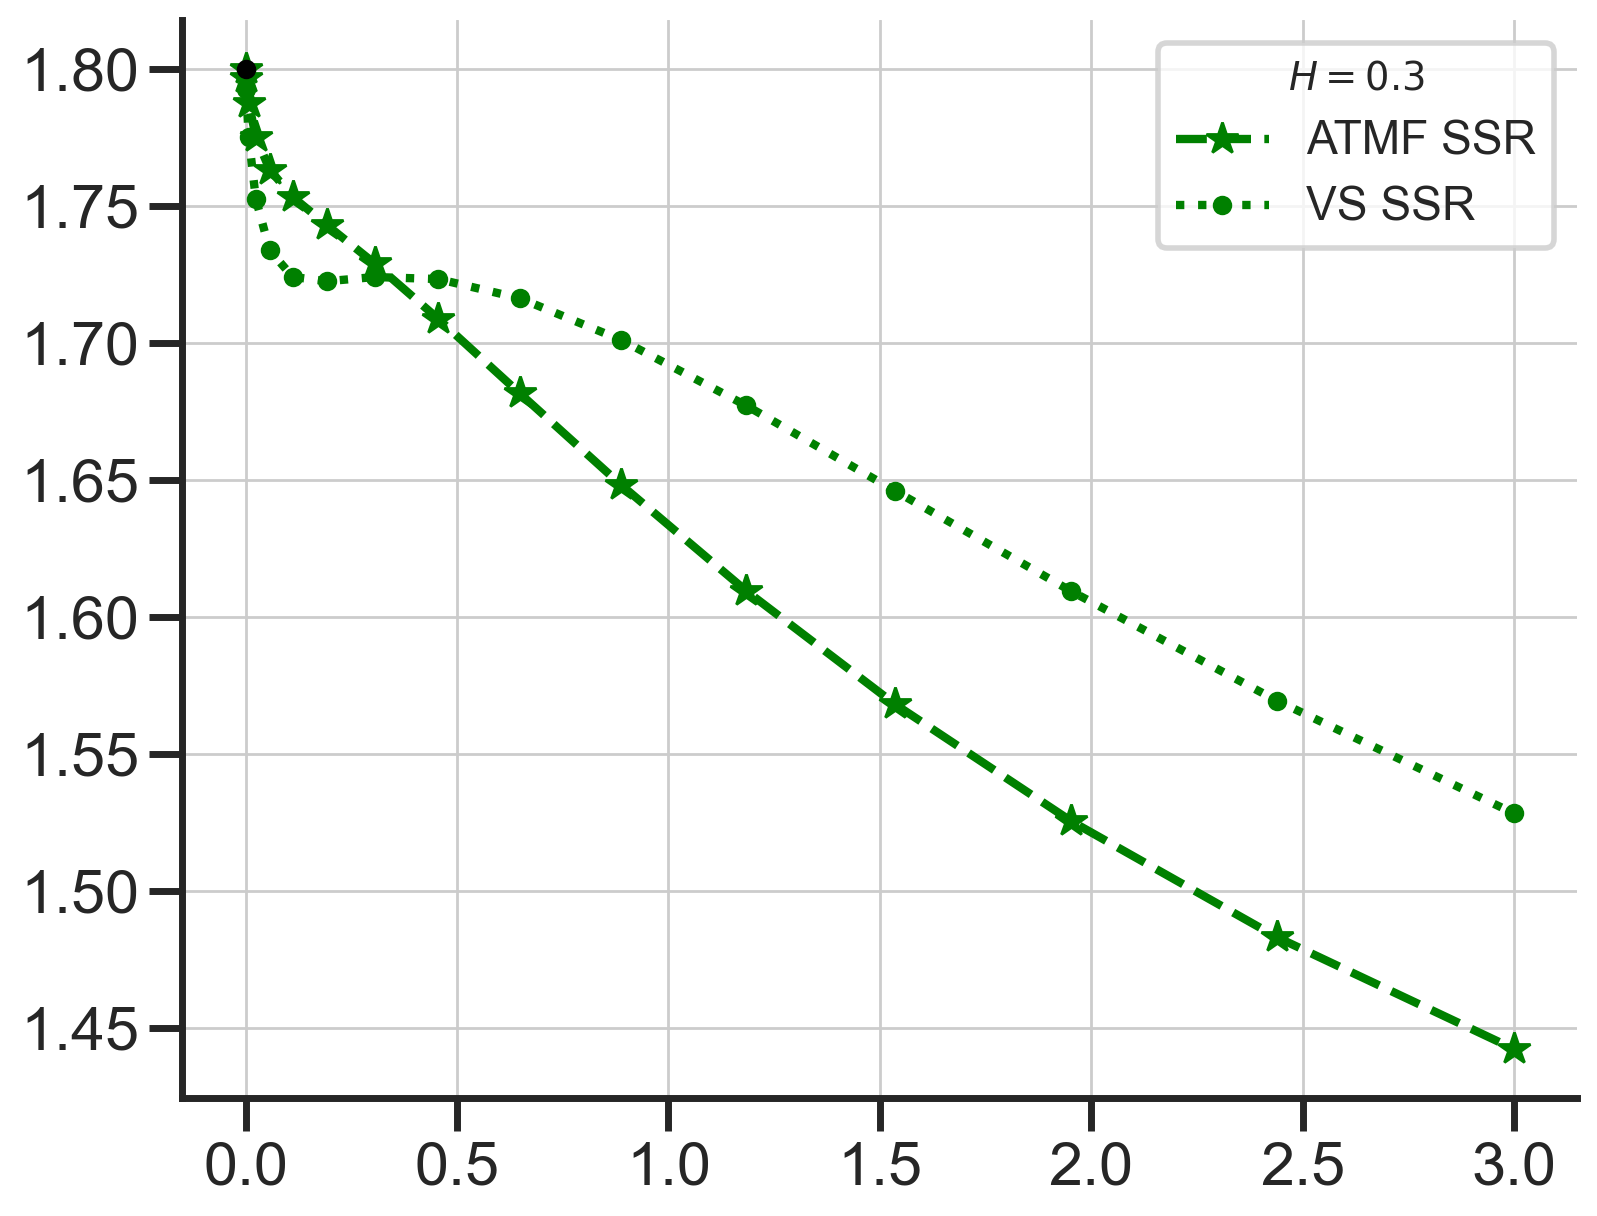

In [20]:
fig, ax = plt.subplots()
ax.plot(Ts, ssr_cf, "*--", color="green", label="ATMF SSR")
ax.plot(Ts, ssr_vs, ":.", color="green", label="VS SSR")
ax.legend(title="$H=0.3$")
ax.plot([0], [0.3 + 3 / 2], ".k")
plt.show()

## H=0.5

In [21]:
H = 0.5 - 1e-3
params, xi0 = get_params_rough_heston(id=1)
params["H"] = H
rheston = RoughHestonModel(params=params, xi0=xi0)
ssr_vs = rheston.ssr_vs(Ts, n_pade=n_pade, n_quad=n_quad)
ssr_cf = rheston.ssr_cf(Ts, n_pade=n_pade, n_quad=n_quad)

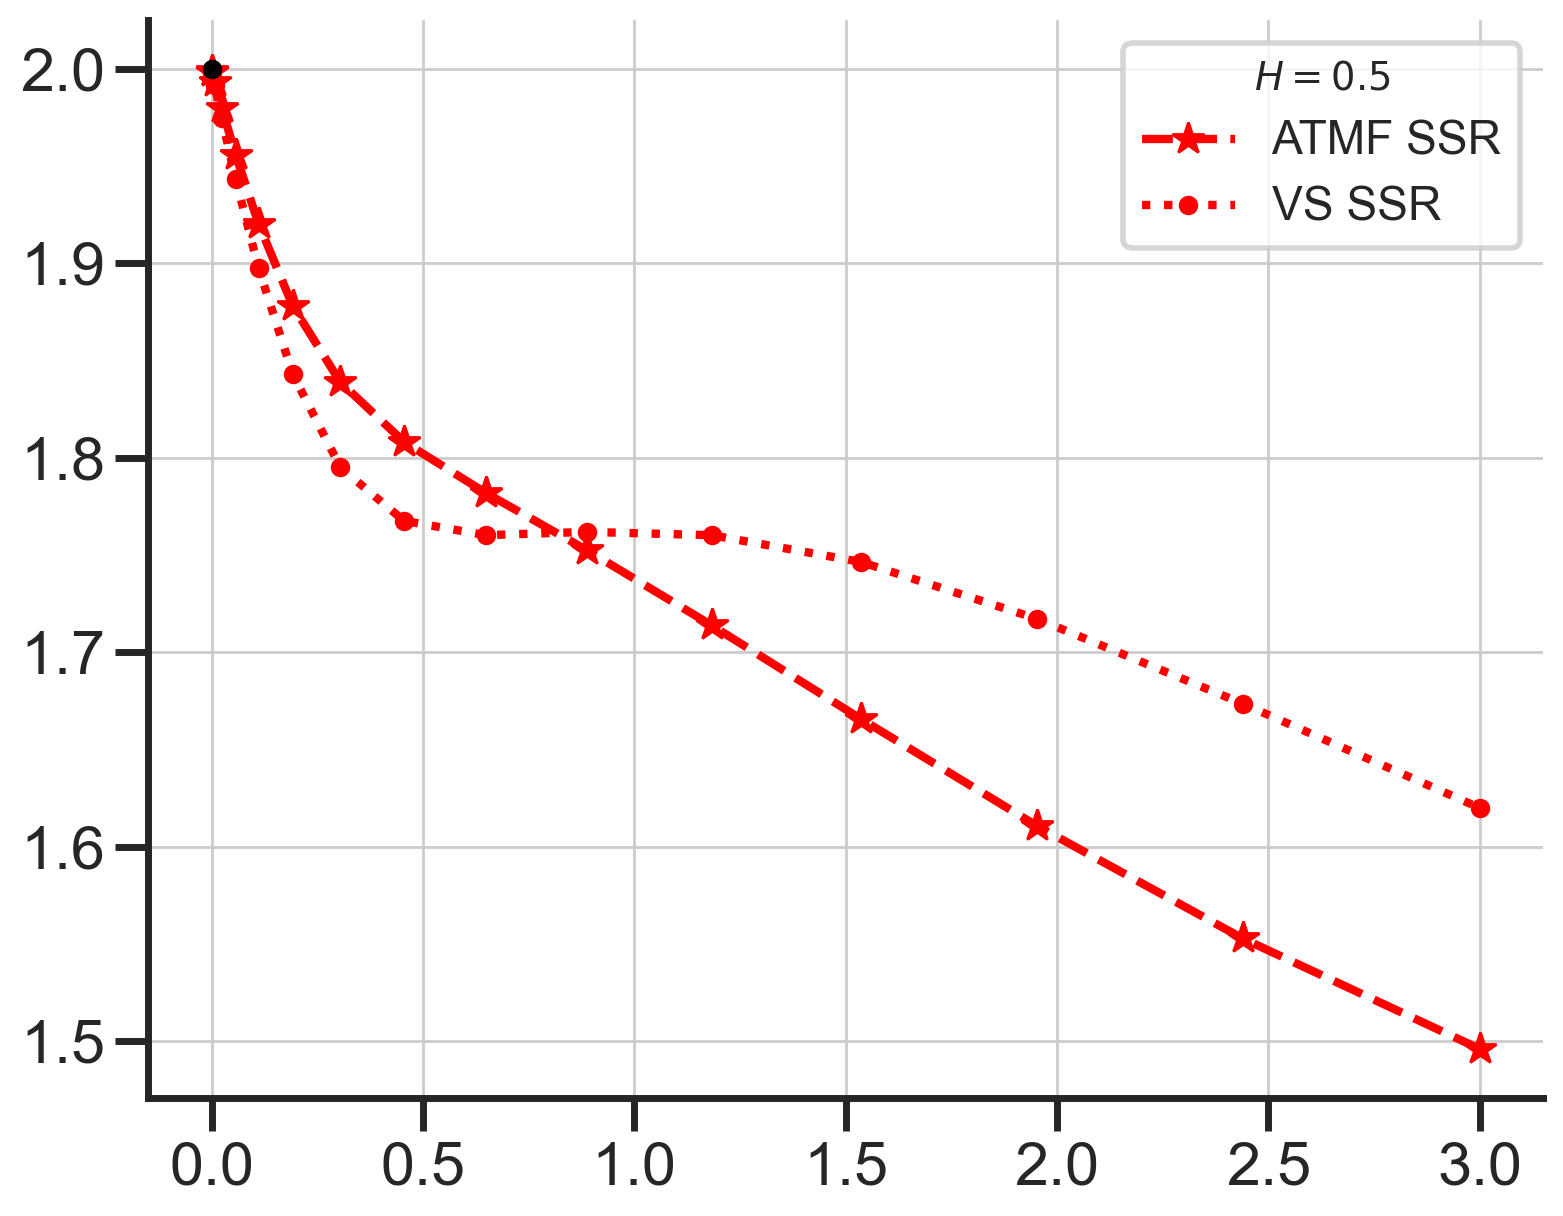

In [22]:
fig, ax = plt.subplots()
ax.plot(Ts, ssr_cf, "*--", color="red", label="ATMF SSR")
ax.plot(Ts, ssr_vs, ":.", color="red", label="VS SSR")
ax.legend(title="$H=0.5$")
ax.plot([0], [2], ".k")
plt.show()

# Market

In [23]:
# parameters
date = DATES[1]
print(f"Using parameters from {date}")

Using parameters from 2024-08-05


In [24]:
# load models
heston = HestonModel(get_params(date=date, model="heston"))
print(heston)
print()

kind_xi0 = "next"
rheston = RoughHestonModel(
    get_params(date=date, model="rough_heston"),
    get_xi0_interpolator(date=date, model="rough_heston", kind=kind_xi0),
)
print(rheston)
print()

rbergomi = RoughBergomiModel(
    get_params(date=date, model="rough_bergomi"),
    get_xi0_interpolator(date=date, model="rough_bergomi", kind=kind_xi0),
)
print(rbergomi)
print()

two_bergomi = TwoFactorBergomiModel(
    get_params(date=date, model="two_bergomi"),
    get_xi0_interpolator(date=date, model="two_bergomi", kind=kind_xi0),
)
print(two_bergomi)

HestonModel with parameters:
v=0.117, kappa=3.37, vbar=0.048, eta=1.99, rho=-0.68, s0=1.0

RoughHestonModel with parameters:
H=0.17, kappa=1.69, eta=0.53, rho=-0.99, s0=1.0

RoughBergomiModel with parameters:
H=0.11, eta=2.39, rho=-0.86, s0=1.0

TwoFactorBergomiModel with parameters:
w=8.99, k1=14.56, k2=2.12, theta=0.32, rho12=-0.69, rhoS1=-0.47, rhoS2=-0.31, s0=1.0


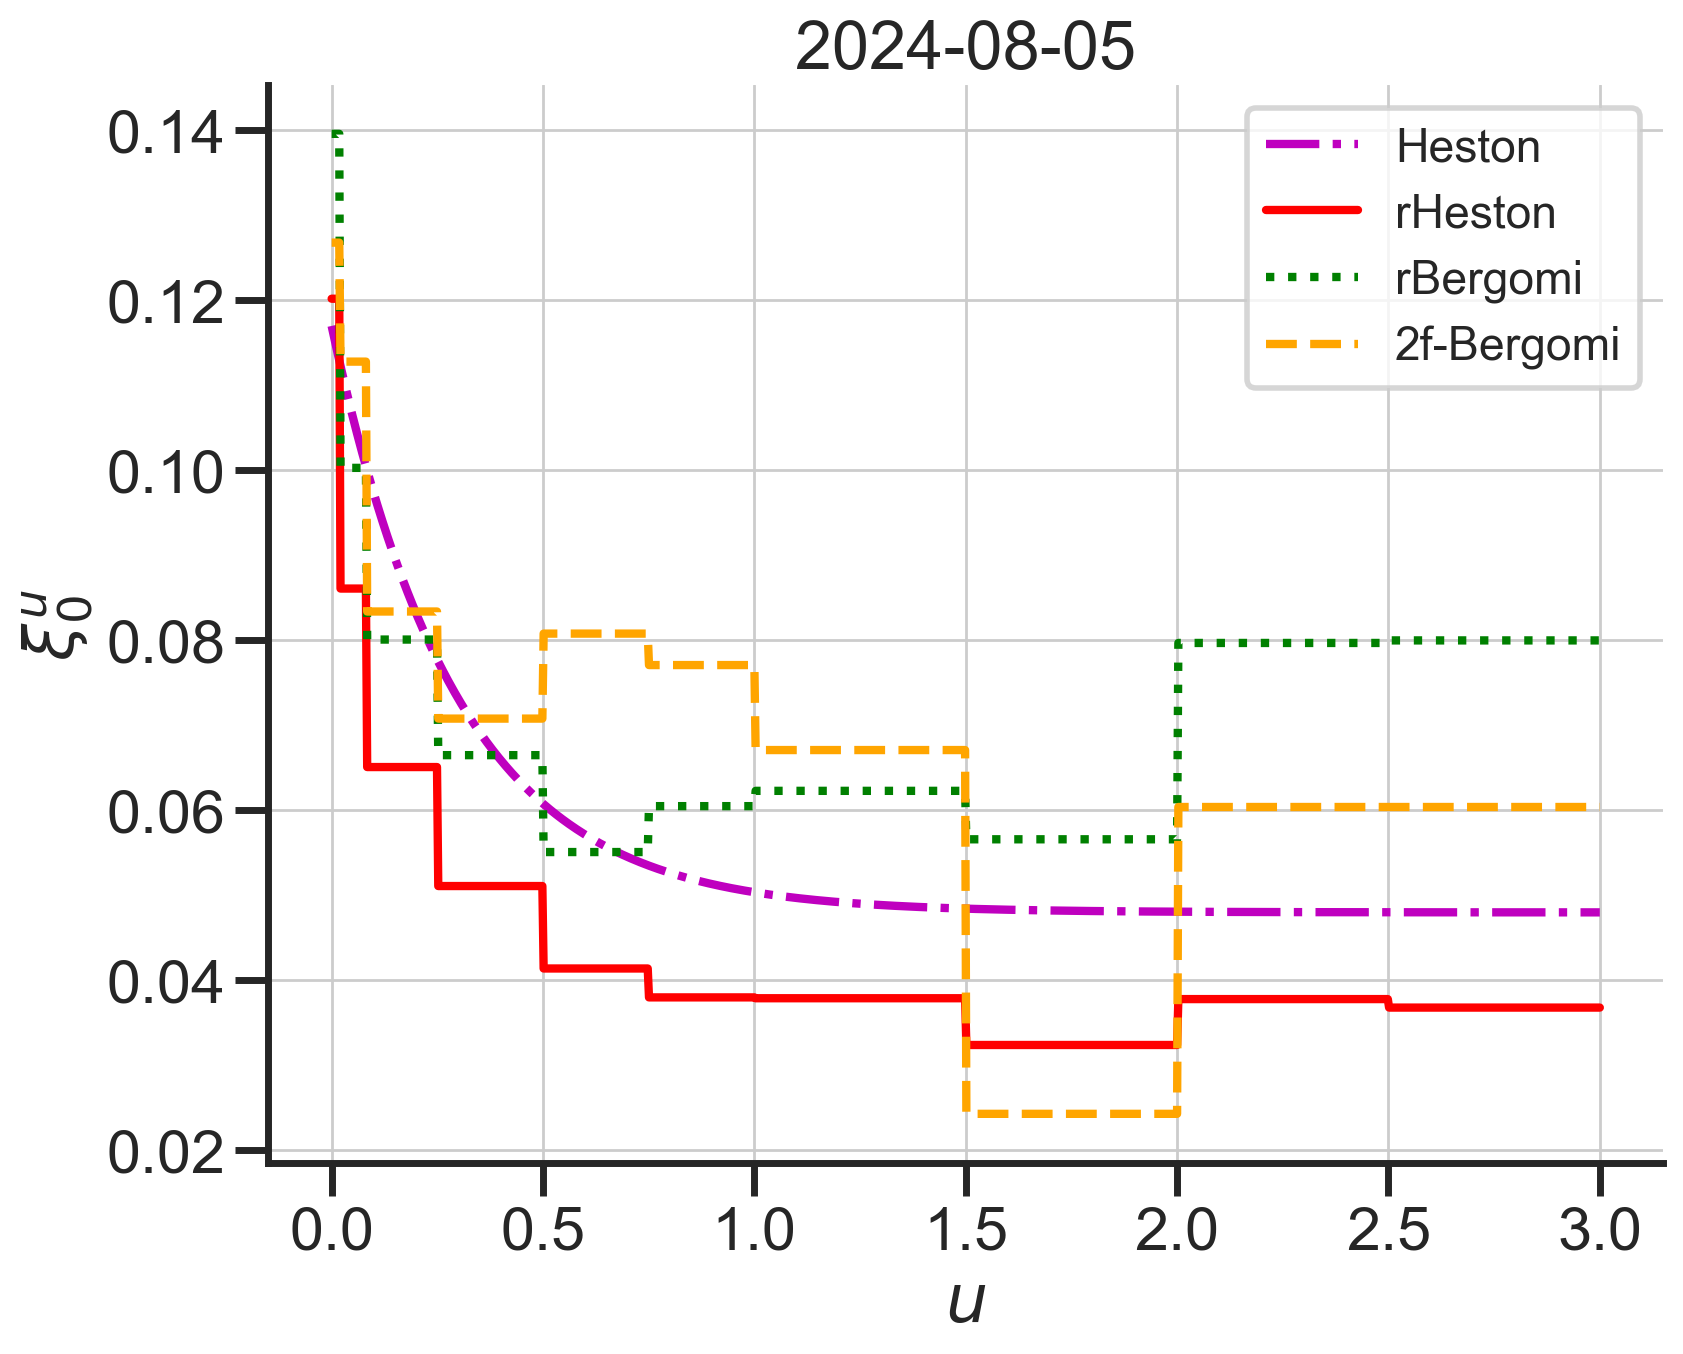

In [25]:
# plot xi0

tab_u = np.linspace(0, 3, 1000)
fig, ax = plt.subplots()
ax.plot(tab_u, heston.xi0(tab_u), "m-.", label="Heston")
ax.plot(tab_u, rheston.xi0(tab_u), "r-", label="rHeston")
ax.plot(tab_u, rbergomi.xi0(tab_u), "g:", label="rBergomi")
ax.plot(tab_u, two_bergomi.xi0(tab_u), "--", color="orange", label="2f-Bergomi")
ax.legend()
ax.set_xlabel("$u$")
ax.set_ylabel(r"$\xi_0^u$")
ax.set_title(date)
plt.show()

In [26]:
Ts = np.array([7 / 365, 1 / 12, 3 / 12, 6 / 12, 9 / 12, 1.0, 1.5, 2.0, 2.5, 3.0])

In [27]:
# Heston SSR
ssr_heston = heston.ssr_all(Ts, eps=1e-3)

In [28]:
# Rough Heston SSR
n_pade = 5
n_quad = 20
ssr_rheston = rheston.ssr_all(Ts, n_pade=n_pade, n_quad=n_quad)

In [29]:
# Monte Carlo parameters for SSR
n_mc = 3 * 10**5
n_disc = 300
n_quad = 40
eps_ssr = 1e-3
n_loop = 6

mc_params = {
    "n_mc": n_mc,
    "n_disc": n_disc,
    "n_quad": n_quad,
    "seed": SEED,
    "eps_ssr": eps_ssr,
    "conditioning": True,
    "n_loop": n_loop,
}

In [30]:
# Rough Bergomi SSR
ssr_rbergomi = rbergomi.ssr_all(Ts, **mc_params)


Computing SSR:
----------------
Model: RoughBergomiModel
Parameters:
Maturity T:  [0.01917808 0.08333333 0.25       0.5        0.75       1.
 1.5        2.         2.5        3.        ]
Monte Carlo paths: 300000
Number of time steps: 300
Finite difference perturbation for SSR: 0.001
Number of simulation loops: 6
Number of independent batches: 1

1/10: expiry 0.0192


/Users/florianbourgey/projects/ssr/model.py:524: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  out = [quad(lambda u, Ti=Ti: self.xi0(Ti * u), 0, 1)[0] for Ti in T]


2/10: expiry 0.0833
3/10: expiry 0.2500
4/10: expiry 0.5000
5/10: expiry 0.7500
6/10: expiry 1.0000
7/10: expiry 1.5000
8/10: expiry 2.0000
9/10: expiry 2.5000
10/10: expiry 3.0000


In [31]:
# Two-factor Bergomi SSR
ssr_two_bergomi = two_bergomi.ssr_all(Ts, **mc_params)


Computing SSR:
----------------
Model: TwoFactorBergomiModel
Parameters:
Maturity T:  [0.01917808 0.08333333 0.25       0.5        0.75       1.
 1.5        2.         2.5        3.        ]
Monte Carlo paths: 300000
Number of time steps: 300
Finite difference perturbation for SSR: 0.001
Number of simulation loops: 6
Number of independent batches: 1

1/10: expiry 0.0192
2/10: expiry 0.0833
3/10: expiry 0.2500
4/10: expiry 0.5000
5/10: expiry 0.7500
6/10: expiry 1.0000
7/10: expiry 1.5000
8/10: expiry 2.0000
9/10: expiry 2.5000
10/10: expiry 3.0000


In [32]:
ssr_rheston

{'ssr_cf': array([1.64195521, 1.55451761, 1.48434266, 1.4259472 , 1.38083753,
        1.35306371, 1.32866676, 1.29691241, 1.28317254, 1.26071439]),
 'ssr_vs': array([1.62308238-3.87246524e-18j, 1.5367909 -2.97160826e-17j,
        1.50107431-3.06149797e-17j, 1.46535176+7.32265558e-17j,
        1.42370959+7.17045442e-18j, 1.39973331-1.79384154e-17j,
        1.38907303-3.43358154e-17j, 1.35439097+1.50831325e-18j,
        1.34705958+5.47133794e-17j, 1.32327657-6.65759763e-18j]),
 'beta': array([-2.86132851, -1.7419458 , -1.07096269, -0.74328928, -0.58737985,
        -0.48566195, -0.36677976, -0.30137414, -0.24830523, -0.21212377]),
 'atm_skew': array([-1.74263494, -1.12057   , -0.72150637, -0.52126003, -0.42537941,
        -0.35893502, -0.27605098, -0.23237818, -0.19350884, -0.1682568 ])}

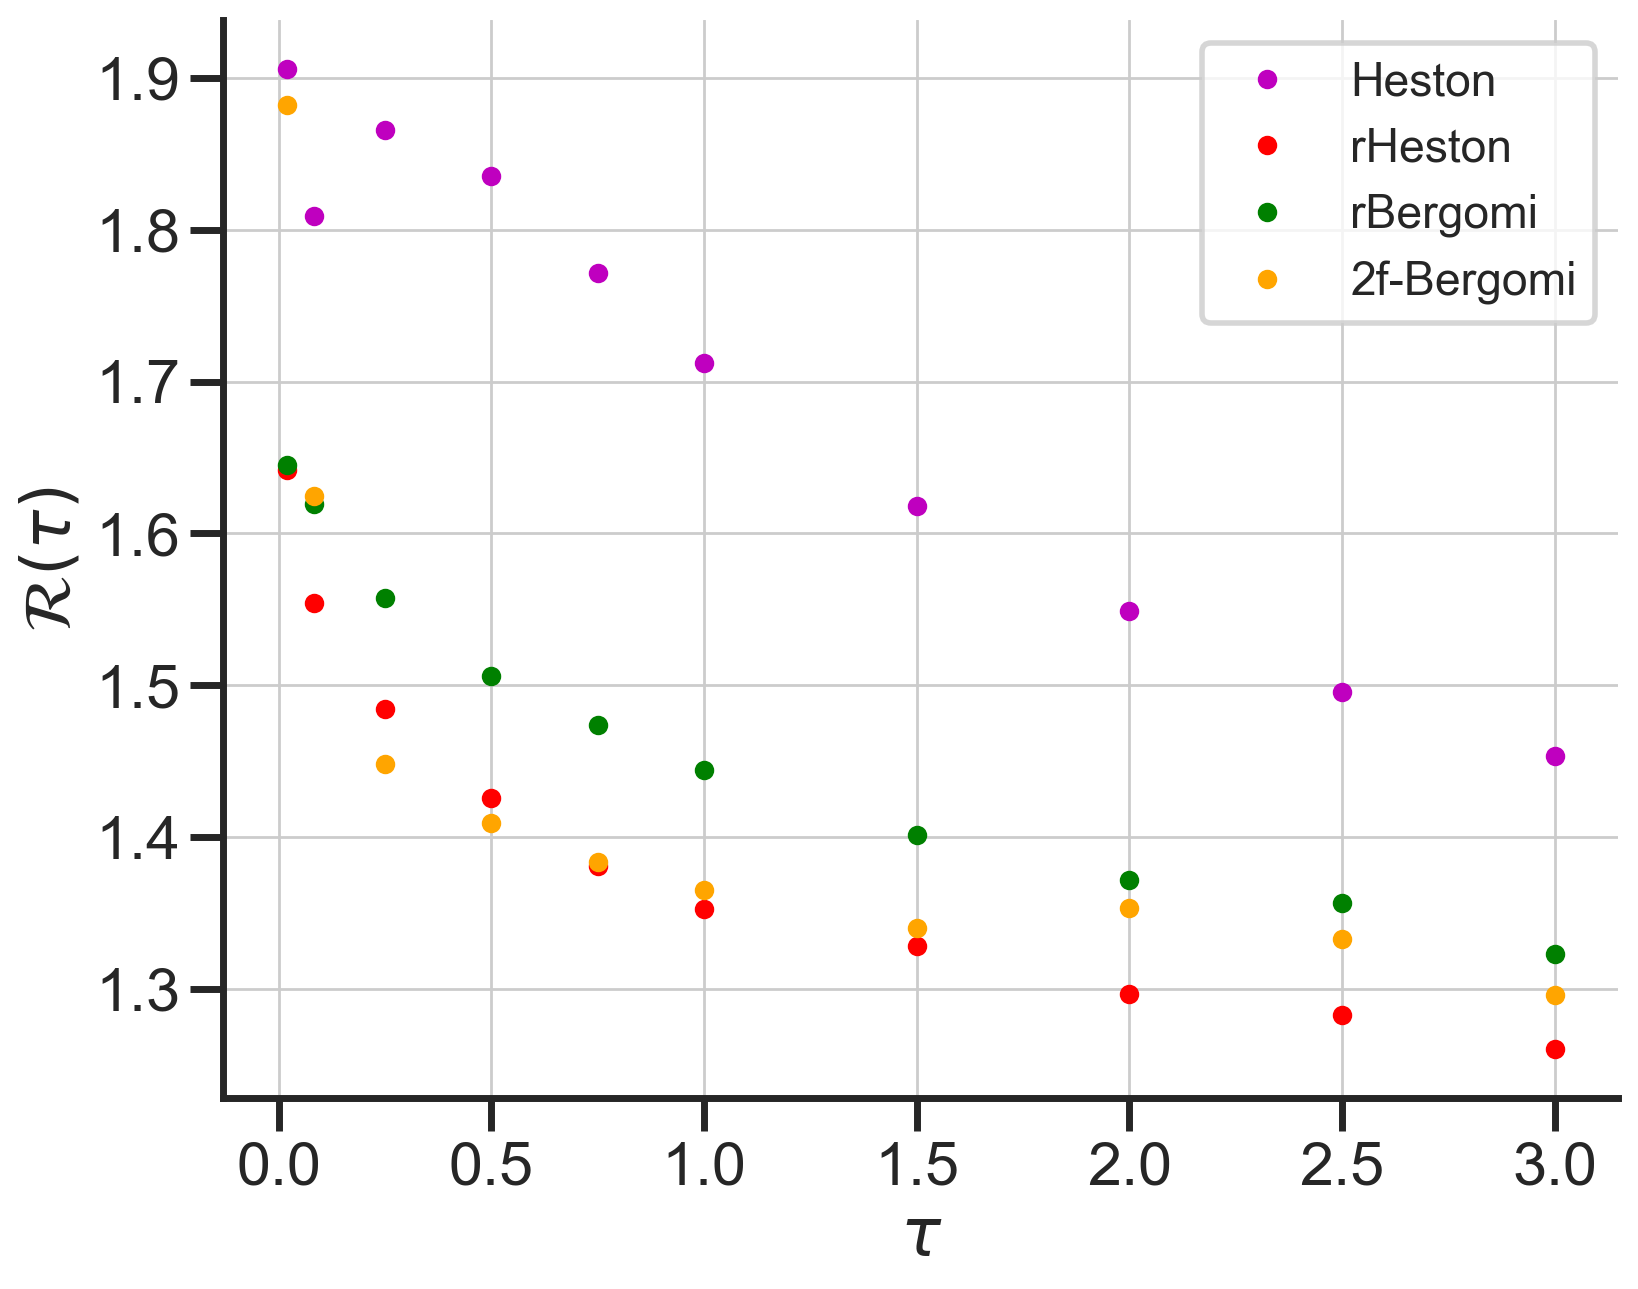

In [33]:
# plot SSR
fig, ax = plt.subplots()
ax.plot(Ts, ssr_heston["ssr_cf"], "m.", label="Heston")
ax.plot(Ts, ssr_rheston["ssr_cf"], "r.", label="rHeston")
ax.plot(Ts, ssr_rbergomi["ssr_fd"], "g.", label="rBergomi")
ax.plot(Ts, ssr_two_bergomi["ssr_fd"], ".", color="orange", label="2f-Bergomi")
ax.legend()
ax.set_xlabel(r"$\tau$")
ax.set_ylabel(r"$\mathcal{R}(\tau)$")
plt.show()

/Users/florianbourgey/projects/ssr/.venv/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/florianbourgey/projects/ssr/.venv/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


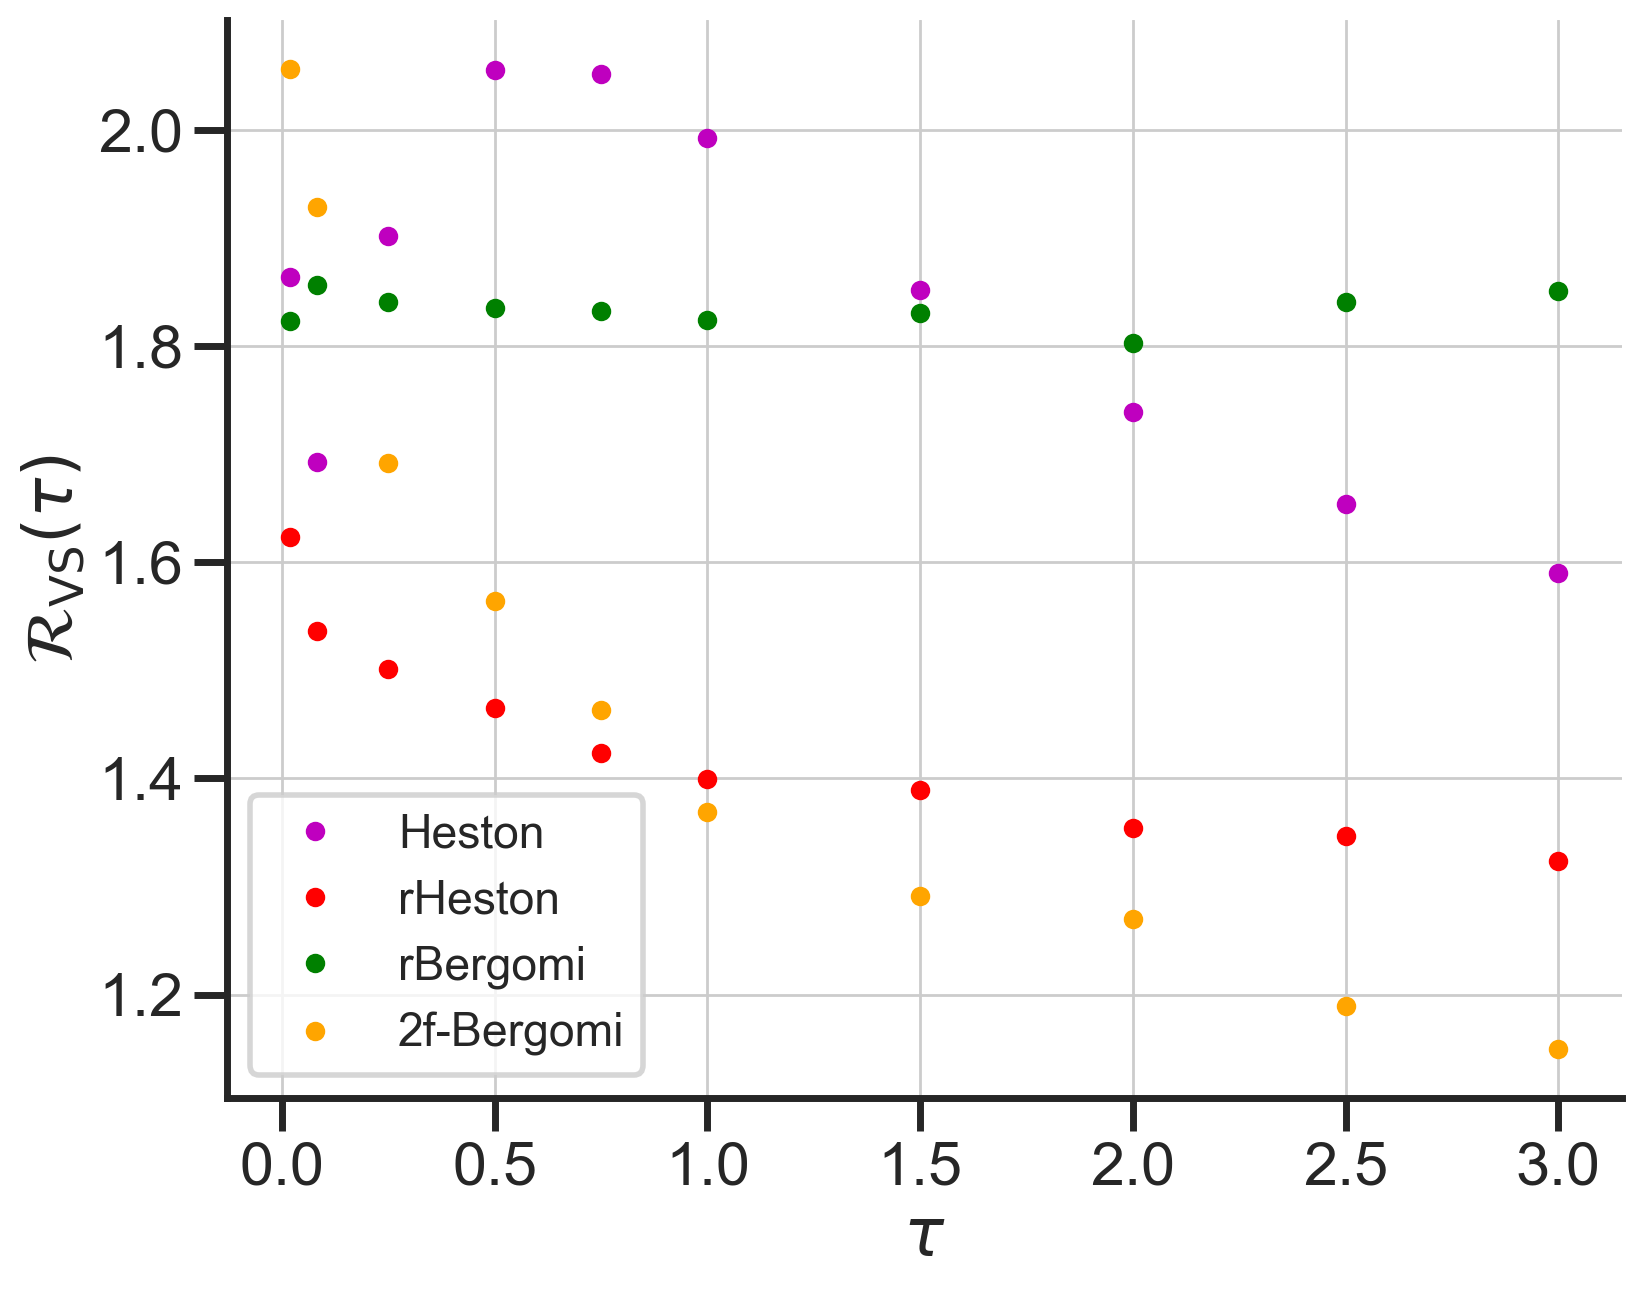

In [34]:
# plot VS SSR
fig, ax = plt.subplots()
ax.plot(Ts, ssr_heston["ssr_vs"], "m.", label="Heston")
ax.plot(Ts, ssr_rheston["ssr_vs"], "r.", label="rHeston")
ax.plot(Ts, ssr_rbergomi["ssr_vs"], "g.", label="rBergomi")
ax.plot(Ts, ssr_two_bergomi["ssr_vs"], ".", color="orange", label="2f-Bergomi")
ax.legend()
ax.set_xlabel(r"$\tau$")
ax.set_ylabel(r"$\mathcal{R}_{\text{VS}}(\tau)$")
plt.show()

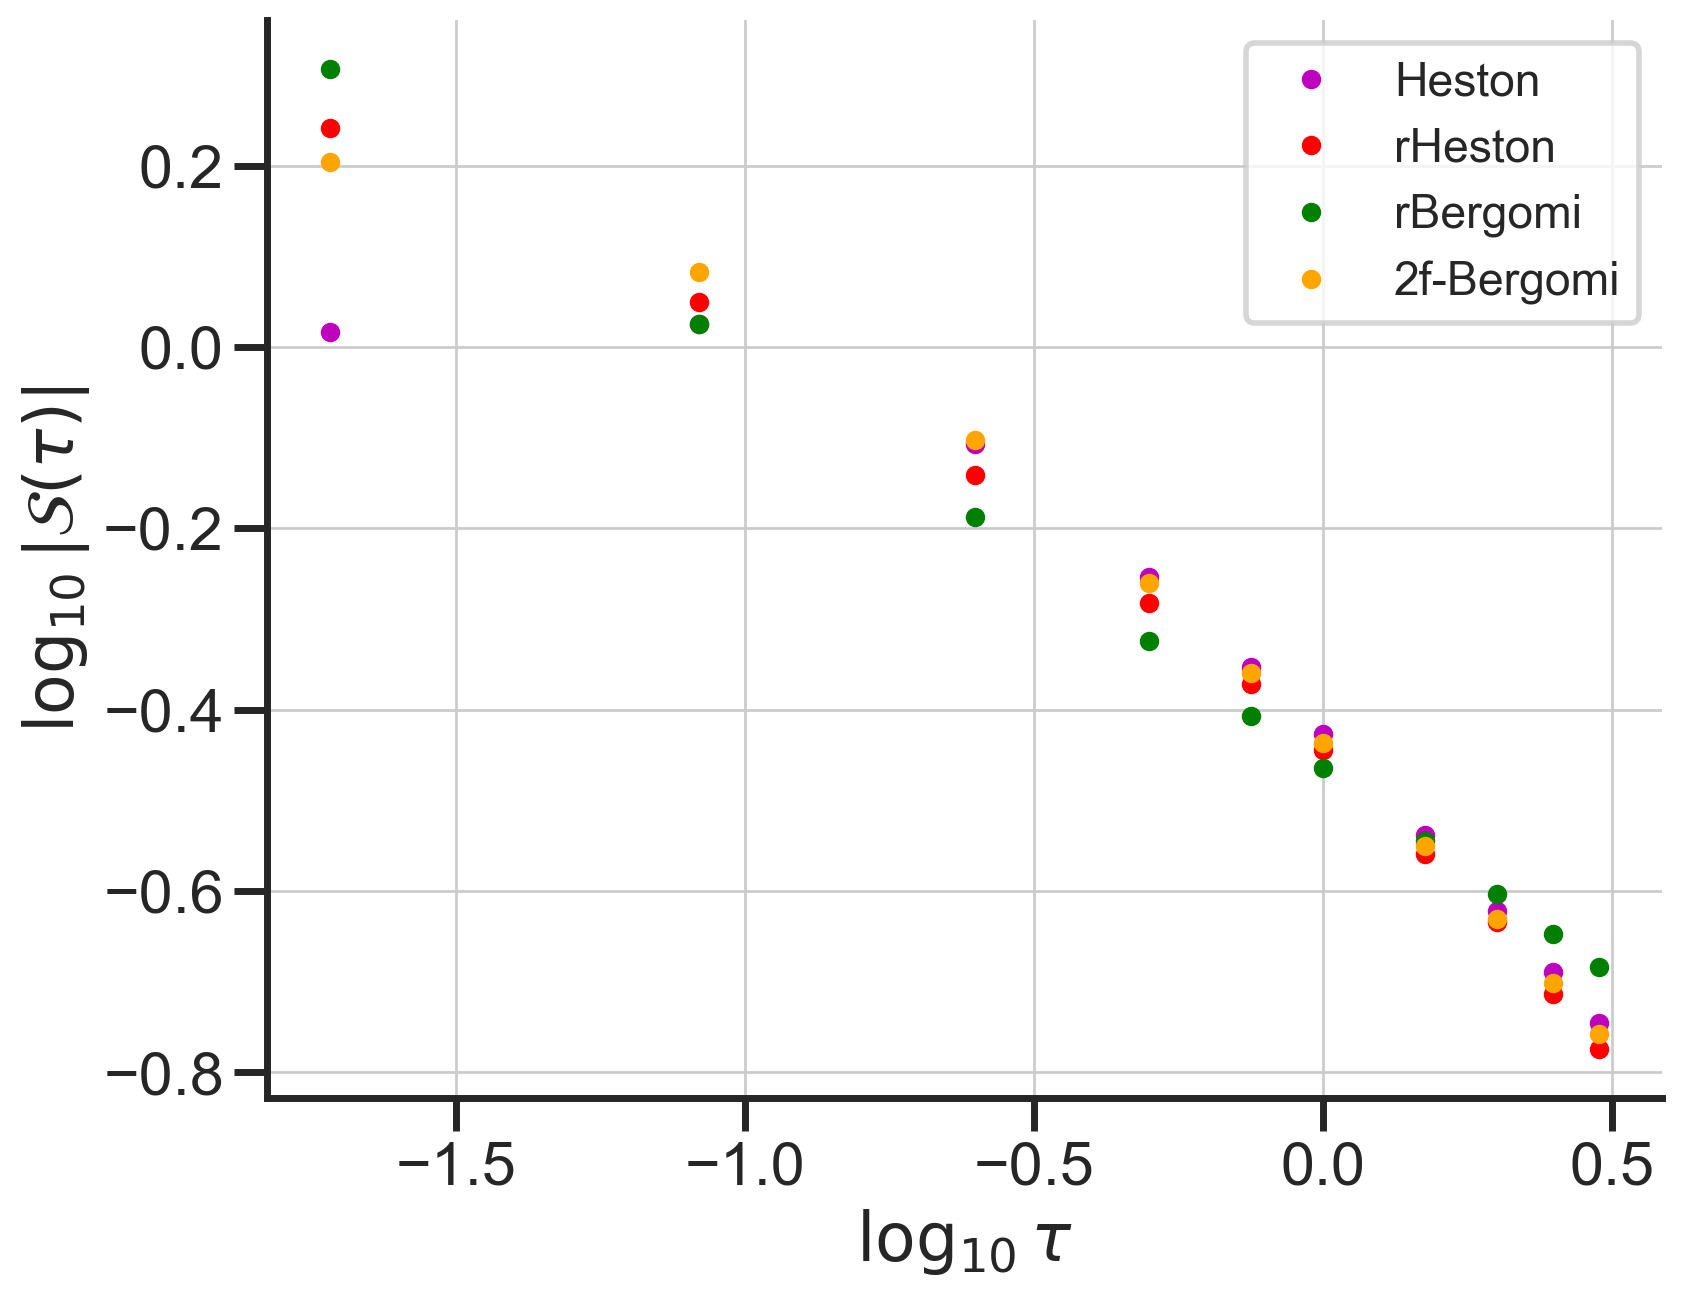

In [35]:
# plot ATM skew

fig, ax = plt.subplots()
ax.plot(np.log10(Ts), np.log10(np.abs(ssr_heston["atm_skew"])), "m.", label="Heston")
ax.plot(np.log10(Ts), np.log10(np.abs(ssr_rheston["atm_skew"])), "r.", label="rHeston")
ax.plot(
    np.log10(Ts), np.log10(np.abs(ssr_rbergomi["atm_skew"])), "g.", label="rBergomi"
)
ax.plot(
    np.log10(Ts),
    np.log10(np.abs(ssr_two_bergomi["atm_skew"])),
    ".",
    color="orange",
    label="2f-Bergomi",
)
ax.legend()
ax.set_xlabel(r"$\log_{10} \tau$")
ax.set_ylabel(r"$\log_{10} |\mathcal{S}(\tau)|$")
plt.show()